# HW3

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## A

In [2]:
df = pd.read_csv("wpbc.data", header=None)

print(df.shape)
print(df.head())

(198, 35)
       0  1    2      3      4       5       6        7       8       9   ...  \
0  119513  N   31  18.02  27.60  117.50  1013.0  0.09489  0.1036  0.1086  ...   
1    8423  N   61  17.99  10.38  122.80  1001.0  0.11840  0.2776  0.3001  ...   
2  842517  N  116  21.37  17.44  137.50  1373.0  0.08836  0.1189  0.1255  ...   
3  843483  N  123  11.42  20.38   77.58   386.1  0.14250  0.2839  0.2414  ...   
4  843584  R   27  20.29  14.34  135.10  1297.0  0.10030  0.1328  0.1980  ...   

       25      26      27      28      29      30      31       32   33  34  
0  139.70  1436.0  0.1195  0.1926  0.3140  0.1170  0.2677  0.08113  5.0   5  
1  184.60  2019.0  0.1622  0.6656  0.7119  0.2654  0.4601  0.11890  3.0   2  
2  159.10  1949.0  0.1188  0.3449  0.3414  0.2032  0.4334  0.09067  2.5   0  
3   98.87   567.7  0.2098  0.8663  0.6869  0.2575  0.6638  0.17300  2.0   0  
4  152.20  1575.0  0.1374  0.2050  0.4000  0.1625  0.2364  0.07678  3.5   0  

[5 rows x 35 columns]


## B

In [3]:
X = df.iloc[:, 3:35]
y = df.iloc[:, 1]

print("Xshape:", X.shape)
print("yshape:", y.shape)

non_recurrent = df[df.iloc[:, 1] == 'N']
recurrent = df[df.iloc[:, 1] == 'R']

print("non-recurrent:", len(non_recurrent))
print("recurrent:", len(recurrent))


Xshape: (198, 32)
yshape: (198,)
non-recurrent: 151
recurrent: 47


In [4]:
train_N = non_recurrent.iloc[:130]
train_R = recurrent.iloc[:37]
record_197 = df.iloc[196:197]
train_df = pd.concat([train_N, train_R, record_197], axis=0)
test_df = df.drop(train_df.index)

X_train = train_df.iloc[:, 3:35]
y_train = train_df.iloc[:, 1]

X_test = test_df.iloc[:, 3:35]
y_test = test_df.iloc[:, 1]

y_train = y_train.map({'N': 0, 'R': 1})
y_test = y_test.map({'N': 0, 'R': 1})

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (168, 32)
y_train: (168,)
X_test : (30, 32)
y_test : (30,)


## C

In [5]:
print((train_df == '?').sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    4
dtype: int64


In [6]:
train_df.iloc[:, 34] = pd.to_numeric(
    train_df.iloc[:, 34],
    errors='coerce'
)

median = train_df.iloc[:, 34].median()

train_df.iloc[:, 34] = train_df.iloc[:, 34].fillna(median)

print((train_df == '?').sum())

X_train = train_df.iloc[:, 3:35]

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
dtype: int64


## D

In [7]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [8]:
y_train_pred = nb.predict(X_train)
y_test_pred = nb.predict(X_test)
y_train_prob = nb.predict_proba(X_train)[:,1]
y_test_prob = nb.predict_proba(X_test)[:,1]

In [9]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Train Confusion Matrix")
print(cm_train)

print("\nTest Confusion Matrix")
print(cm_test)

Train Confusion Matrix
[[98 32]
 [20 18]]

Test Confusion Matrix
[[14  7]
 [ 6  3]]


In [10]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Train Precision:",
      precision_score(y_train,y_train_pred))

print("Train Recall:",
      recall_score(y_train,y_train_pred))

print("Train F1:",
      f1_score(y_train,y_train_pred))

print("Test Precision:",
      precision_score(y_test,y_test_pred))

print("Test Recall:",
      recall_score(y_test,y_test_pred))

print("Test F1:",
      f1_score(y_test,y_test_pred))

Train Precision: 0.36
Train Recall: 0.47368421052631576
Train F1: 0.40909090909090906
Test Precision: 0.3
Test Recall: 0.3333333333333333
Test F1: 0.3157894736842105


In [11]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score( y_train,y_train_prob)

test_auc = roc_auc_score( y_test, y_test_prob)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.6757085020242914
Test AUC: 0.5555555555555556


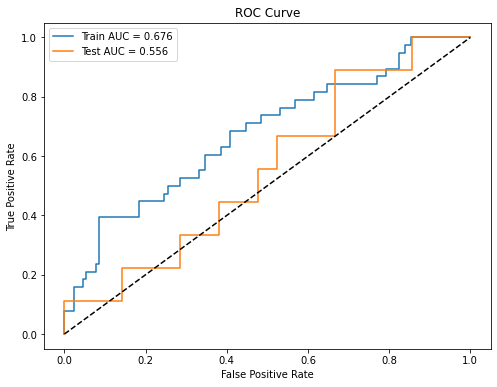

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_train, tpr_train, _ = roc_curve(
    y_train,
    y_train_prob
)

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {train_auc:.3f}"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Test AUC = {test_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

Before resampling: Counter({0: 130, 1: 38})
Major class: 0 count = 130
Minor class: 1 count = 38

After under-sampling: Counter({0: 90, 1: 38})
After SMOTE: Counter({0: 90, 1: 90})

===== TRAIN (after SMOTE) =====
Confusion Matrix:
[[64 26]
 [31 59]]
Precision: 0.6941176470588235
Recall: 0.6555555555555556
F1: 0.6742857142857143
AUC: 0.7472839506172839

===== TEST =====
Confusion Matrix:
[[14  7]
 [ 5  4]]
Precision: 0.36363636363636365
Recall: 0.4444444444444444
F1: 0.39999999999999997
AUC: 0.6931216931216931


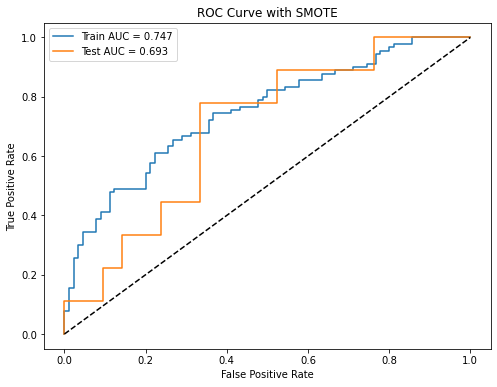

In [13]:
from collections import Counter
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 先确认类别分布
print("Before resampling:", Counter(y_train))

# 找出多数类和少数类
class_counts = Counter(y_train)
major_class = max(class_counts, key=class_counts.get)
minor_class = min(class_counts, key=class_counts.get)

print("Major class:", major_class, "count =", class_counts[major_class])
print("Minor class:", minor_class, "count =", class_counts[minor_class])

# 1) 先把多数类下采样到 90
rus = RandomUnderSampler(
    sampling_strategy={major_class: 90},
    random_state=42
)

X_under, y_under = rus.fit_resample(X_train, y_train)

print("\nAfter under-sampling:", Counter(y_under))

# 2) 再把少数类用 SMOTE 上采样到 90，k=5
smote = SMOTE(
    sampling_strategy={minor_class: 90},
    k_neighbors=5,
    random_state=42
)

X_res, y_res = smote.fit_resample(X_under, y_under)

print("After SMOTE:", Counter(y_res))

# 3) 用平衡后的训练集重新训练 GaussianNB
nb_smote = GaussianNB()
nb_smote.fit(X_res, y_res)

# 4) 训练集预测
y_train_pred = nb_smote.predict(X_res)
y_train_prob = nb_smote.predict_proba(X_res)[:, 1]

# 5) 测试集预测
y_test_pred = nb_smote.predict(X_test)
y_test_prob = nb_smote.predict_proba(X_test)[:, 1]

# 6) 指标函数
def report(y_true, y_pred, y_prob, name):
    print(f"\n===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_prob))

# 7) 输出训练集和测试集结果
report(y_res, y_train_pred, y_train_prob, "TRAIN (after SMOTE)")
report(y_test, y_test_pred, y_test_prob, "TEST")

# 8) 画 ROC
fpr_train, tpr_train, _ = roc_curve(y_res, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {roc_auc_score(y_res, y_train_prob):.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with SMOTE")
plt.legend()
plt.show()

SMOTE helped. The test AUC increased from 0.556 to 0.693, and the classifier became more effective at detecting recurrent cases. Therefore, balancing the training data improved the overall predictive performance.

## E

In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

from imblearn.over_sampling import SMOTE


# =========================================================
# 1) Prepare regression data
#    y_reg  = time to recurrence (column 3)
#    X      = columns 4~35 (32 features)
#    y_cls  = Outcome (column 2), only used for stratified split / SMOTE
# =========================================================

X_train_full = train_df.iloc[:, 3:35].copy()
X_test = test_df.iloc[:, 3:35].copy()

y_train_time = pd.to_numeric(train_df.iloc[:, 2], errors='coerce').copy()
y_test_time = pd.to_numeric(test_df.iloc[:, 2], errors='coerce').copy()

y_train_class = train_df.iloc[:, 1].astype(str).copy()
y_test_class = test_df.iloc[:, 1].astype(str).copy()

# Make sure features are numeric
X_train_full = X_train_full.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill any remaining missing feature values with training medians
train_medians = X_train_full.median()
X_train_full = X_train_full.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Drop rows with missing regression target if any
mask_train = y_train_time.notna()
X_train_full = X_train_full.loc[mask_train].reset_index(drop=True)
y_train_time = y_train_time.loc[mask_train].reset_index(drop=True)
y_train_class = y_train_class.loc[mask_train].reset_index(drop=True)

mask_test = y_test_time.notna()
X_test = X_test.loc[mask_test].reset_index(drop=True)
y_test_time = y_test_time.loc[mask_test].reset_index(drop=True)
y_test_class = y_test_class.loc[mask_test].reset_index(drop=True)

print("Original training class distribution:")
print(y_train_class.value_counts())
print("\nOriginal training regression target shape:", y_train_time.shape)
print("Original test regression target shape:", y_test_time.shape)


# =========================================================
# 2) Helper: tune k on a validation split
# =========================================================

def tune_knn_regressor(X_tr, y_tr, X_val, y_val, k_values=range(1, 21)):
    best_k = None
    best_mse = float('inf')
    results = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsRegressor(n_neighbors=k, metric='euclidean')
        )
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        mse = mean_squared_error(y_val, pred_val)
        results.append((k, mse))

        if mse < best_mse:
            best_mse = mse
            best_k = k

    return best_k, best_mse, results


# =========================================================
# 3) Original training set: 80/20 split stratified by class
# =========================================================

X_sub, X_val, y_sub_time, y_val_time, y_sub_class, y_val_class = train_test_split(
    X_train_full,
    y_train_time,
    y_train_class,
    test_size=0.2,
    random_state=42,
    stratify=y_train_class
)

best_k, best_val_mse, cv_results = tune_knn_regressor(X_sub, y_sub_time, X_val, y_val_time)

print("\n===== Original training set =====")
print("Best k =", best_k)
print("Validation MSE =", best_val_mse)

# Train on the whole original training set using best k
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=best_k, metric='euclidean')
)
final_model.fit(X_train_full, y_train_time)

y_train_pred = final_model.predict(X_train_full)
y_test_pred = final_model.predict(X_test)

train_mse = mean_squared_error(y_train_time, y_train_pred)
test_mse = mean_squared_error(y_test_time, y_test_pred)

print("Train MSE =", train_mse)
print("Test MSE  =", test_mse)


# =========================================================
# 4) SMOTE on the training set
#    SMOTE is for classification, so we use Outcome only
#    to balance the classes.
#
#    Since the regression target is continuous, we need a
#    practical way to assign time-to-recurrence to synthetic
#    samples. Here we approximate synthetic times using a
#    KNN regressor trained on the original minority class.
# =========================================================

# Identify minority class
class_counts = y_train_class.value_counts()
minority_label = class_counts.idxmin()

print("\nMinority class =", minority_label)
print("Counts before SMOTE:")
print(class_counts)

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    random_state=42
)

X_smote, y_class_smote = smote.fit_resample(X_train_full, y_train_class)

X_smote = pd.DataFrame(X_smote, columns=X_train_full.columns)
y_class_smote = pd.Series(y_class_smote)

print("\nCounts after SMOTE:")
print(y_class_smote.value_counts())

# Original rows are kept first by imblearn; synthetic rows are appended
n_original = len(X_train_full)
n_total = len(X_smote)
n_synth = n_total - n_original

# Approximate regression target for synthetic samples using minority-class neighbors
minority_mask = (y_train_class == minority_label)

time_knn_for_synth = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=5, weights='distance', metric='euclidean')
)
time_knn_for_synth.fit(
    X_train_full.loc[minority_mask].reset_index(drop=True),
    y_train_time.loc[minority_mask].reset_index(drop=True)
)

X_synth = X_smote.iloc[n_original:].reset_index(drop=True)
y_synth_time = time_knn_for_synth.predict(X_synth)

y_smote_time = np.concatenate([y_train_time.values, y_synth_time])

print("\nSMOTE-balanced training set size:", X_smote.shape)
print("SMOTE-balanced regression target size:", y_smote_time.shape)


# =========================================================
# 5) Re-tune k on the SMOTE-balanced training set
# =========================================================

X_sub_s, X_val_s, y_sub_time_s, y_val_time_s, y_sub_class_s, y_val_class_s = train_test_split(
    X_smote,
    y_smote_time,
    y_class_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_class_smote
)

best_k_smote, best_val_mse_smote, cv_results_smote = tune_knn_regressor(
    X_sub_s, y_sub_time_s, X_val_s, y_val_time_s
)

print("\n===== SMOTE-balanced training set =====")
print("Best k =", best_k_smote)
print("Validation MSE =", best_val_mse_smote)

# Train on the full SMOTE-balanced training set
final_model_smote = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=best_k_smote, metric='euclidean')
)
final_model_smote.fit(X_smote, y_smote_time)

y_train_pred_smote = final_model_smote.predict(X_smote)
y_test_pred_smote = final_model_smote.predict(X_test)

train_mse_smote = mean_squared_error(y_smote_time, y_train_pred_smote)
test_mse_smote = mean_squared_error(y_test_time, y_test_pred_smote)

print("Train MSE after SMOTE =", train_mse_smote)
print("Test MSE after SMOTE  =", test_mse_smote)


# =========================================================
# 6) Final comparison
# =========================================================

print("\n===== Summary =====")
print("Original best k:", best_k)
print("Original train MSE:", train_mse)
print("Original test MSE :", test_mse)

print("\nSMOTE best k:", best_k_smote)
print("SMOTE train MSE:", train_mse_smote)
print("SMOTE test MSE :", test_mse_smote)

if test_mse_smote < test_mse:
    print("\nConclusion: SMOTE helps reduce test MSE.")
elif test_mse_smote > test_mse:
    print("\nConclusion: SMOTE does not help; test MSE increased.")
else:
    print("\nConclusion: SMOTE makes little difference in test MSE.")

Original training class distribution:
N    130
R     38
Name: 1, dtype: int64

Original training regression target shape: (168,)
Original test regression target shape: (30,)

===== Original training set =====
Best k = 18
Validation MSE = 776.980119825708
Train MSE = 919.9457671957673
Test MSE  = 1602.8401234567903

Minority class = R
Counts before SMOTE:
N    130
R     38
Name: 1, dtype: int64

Counts after SMOTE:
N    130
R    130
Name: 1, dtype: int64

SMOTE-balanced training set size: (260, 32)
SMOTE-balanced regression target size: (260,)

===== SMOTE-balanced training set =====
Best k = 14
Validation MSE = 632.6257744940317
Train MSE after SMOTE = 666.3378665153484
Test MSE after SMOTE  = 1137.3266835269105

===== Summary =====
Original best k: 18
Original train MSE: 919.9457671957673
Original test MSE : 1602.8401234567903

SMOTE best k: 14
SMOTE train MSE: 666.3378665153484
SMOTE test MSE : 1137.3266835269105

Conclusion: SMOTE helps reduce test MSE.
